# **Project Name**    - World Bank Global Education Analysis



##### **Project Type**    - EDA + Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey

# **Project Summary -**

This project focuses on analyzing global education indicators using the World Bank EdStats dataset to uncover patterns in literacy, education expenditure, and inequality across countries. The objective is to transform raw educational data into meaningful insights that can help governments, policymakers, and international organizations improve education systems worldwide.

The dataset consists of thousands of indicators covering various aspects of education such as literacy rate, enrollment, completion, government spending, and demographic trends across multiple countries and years. Due to its wide and complex structure, the dataset required extensive preprocessing including filtering relevant indicators, reshaping data from wide to long format, handling missing values, and correcting data types.

A structured Exploratory Data Analysis (EDA) approach was followed using the UBM rule (Univariate, Bivariate, and Multivariate analysis). Multiple visualizations were created to understand the distribution of literacy rates, trends over time, country-level comparisons, and relationships between variables. The analysis revealed that global literacy rates have significantly improved over time, but strong disparities still exist between developed and developing countries.

One of the key insights from the analysis is that education spending has a positive impact on literacy rates, but efficiency varies significantly. Some countries achieve high literacy with moderate spending, indicating better policy implementation and resource utilization. Additionally, a group of countries still struggles with low literacy rates, highlighting the need for targeted interventions.

Feature engineering was performed to create meaningful variables such as a binary classification target for high literacy levels. Machine learning models including Logistic Regression, Decision Tree, and Random Forest were implemented to classify countries based on literacy performance. Among these models, Random Forest performed the best due to its ability to capture complex and non-linear relationships in the data.

Model evaluation was conducted using accuracy, confusion matrix, precision, recall, and F1-score. Hyperparameter tuning and cross-validation were applied to improve model performance and ensure robustness.

The project concludes with actionable business recommendations such as increasing targeted education spending, focusing on female education, and improving policy efficiency. These insights can help stakeholders design better education strategies and reduce global inequality.

Overall, this project demonstrates strong analytical, visualization, and machine learning skills while delivering real-world business insights.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to analyze global education data to identify key factors affecting literacy rates across countries. The study aims to uncover patterns, trends, and disparities in education systems worldwide and build a machine learning model to classify countries based on literacy performance.

The project also focuses on understanding how education spending influences literacy outcomes and whether all countries utilize resources efficiently. By analyzing these relationships, the goal is to provide actionable insights that can help policymakers and global organizations improve education quality and accessibility.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set_style("whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load Dataset

data = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsData.csv')
country = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsCountry.csv')
series = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsSeries.csv')
country_series = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsCountry-Series.csv')
footnote = pd.read_csv('/content/drive/MyDrive/Projects/World Bank/World Bank Data/EdStatsFootNote.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Dataset First View

In [ ]:
# Dataset First Look

data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1970,1971,1972,1973,1974,1975,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
0,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.GPI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Arab World,ARB,"Adjusted net enrolment rate, lower secondary, ...",UIS.NERA.2.M,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Arab World,ARB,"Adjusted net enrolment rate, primary, both sex...",SE.PRM.TENR,54.822121,54.894138,56.209438,57.267109,57.991138,59.36554,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 886930
Columns: 70


### Dataset Information

In [ ]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886930 entries, 0 to 886929
Data columns (total 70 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Country Name    886930 non-null  object 
 1   Country Code    886930 non-null  object 
 2   Indicator Name  886930 non-null  object 
 3   Indicator Code  886930 non-null  object 
 4   1970            72288 non-null   float64
 5   1971            35537 non-null   float64
 6   1972            35619 non-null   float64
 7   1973            35545 non-null   float64
 8   1974            35730 non-null   float64
 9   1975            87306 non-null   float64
 10  1976            37483 non-null   float64
 11  1977            37574 non-null   float64
 12  1978            37576 non-null   float64
 13  1979            36809 non-null   float64
 14  1980            89122 non-null   float64
 15  1981            38777 non-null   float64
 16  1982            37511 non-null   float64
 17  1983      

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count

duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count

missing_values = data.isnull().sum()
missing_values.sort_values(ascending=False).head(10)

,0
Unnamed: 69,886930
2017,886787
2016,870470
1971,851393
1973,851385
1972,851311
1974,851200
1979,850121
1976,849447
1982,849419


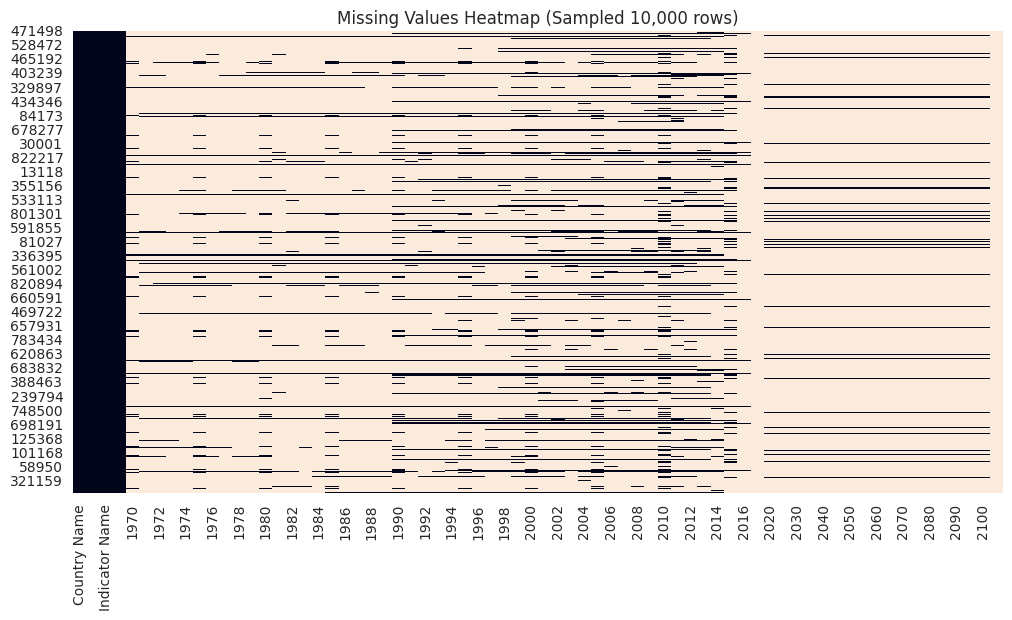

In [ ]:
# Visualizing the missing values (using a sample for speed)

plt.figure(figsize=(12,6))
sns.heatmap(data.sample(10000, random_state=42).isnull(), cbar=False)
plt.title("Missing Values Heatmap (Sampled 10,000 rows)")
plt.show()

### What did you know about your dataset?


- The dataset contains global education indicators across multiple countries and years.
- It is a wide dataset with year-wise columns.
- There are significant missing values present.
- Data requires cleaning and transformation before analysis.
- Not all indicators are relevant, so filtering is necessary.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
data.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2020', '2025', '2030', '2035', '2040', '2045',
       '2050', '2055', '2060', '2065', '2070', '2075', '2080', '2085', '2090',
       '2095', '2100', 'Unnamed: 69'],
      dtype='object')

In [ ]:
# Dataset Describe
data.describe()

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2060,2065,2070,2075,2080,2085,2090,2095,2100,Unnamed: 69
count,7.228800e+04,3.553700e+04,3.561900e+04,3.554500e+04,3.573000e+04,8.730600e+04,3.748300e+04,3.757400e+04,3.757600e+04,3.680900e+04,...,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,5.143600e+04,0.0
mean,1.974772e+09,4.253638e+09,4.592365e+09,5.105006e+09,5.401493e+09,2.314288e+09,5.731808e+09,6.124437e+09,6.671489e+09,7.436724e+09,...,7.224868e+02,7.271290e+02,7.283779e+02,7.266484e+02,7.228327e+02,7.176899e+02,7.113072e+02,7.034274e+02,6.940296e+02,NaN
std,1.211687e+11,1.804814e+11,1.914083e+11,2.059170e+11,2.112150e+11,1.375059e+11,2.215546e+11,2.325489e+11,2.473986e+11,2.660957e+11,...,2.215845e+04,2.287990e+04,2.352338e+04,2.408149e+04,2.455897e+04,2.496587e+04,2.530183e+04,2.556069e+04,2.574189e+04,NaN
min,-1.435564e+00,-1.594625e+00,-3.056522e+00,-4.032582e+00,-4.213563e+00,-3.658569e+00,-2.950945e+00,-3.174870e+00,-3.558749e+00,-2.973612e+00,...,-1.630000e+00,-1.440000e+00,-1.260000e+00,-1.090000e+00,-9.200000e-01,-7.800000e-01,-6.500000e-01,-5.500000e-01,-4.500000e-01,NaN
25%,8.900000e-01,8.853210e+00,9.240920e+00,9.595200e+00,9.861595e+00,1.400000e+00,9.312615e+00,9.519913e+00,1.000000e+01,1.000000e+01,...,3.000000e-02,3.000000e-02,2.000000e-02,2.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,1.000000e-02,NaN
50%,6.317724e+00,6.316240e+01,6.655139e+01,6.969595e+01,7.087760e+01,9.677420e+00,7.101590e+01,7.133326e+01,7.290512e+01,7.510173e+01,...,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.300000e-01,2.200000e-01,NaN
75%,6.251250e+01,5.655200e+04,5.863650e+04,6.202900e+04,6.383675e+04,7.854163e+01,5.682800e+04,5.739175e+04,5.940425e+04,6.411500e+04,...,7.505000e+00,7.500000e+00,7.300000e+00,7.100000e+00,6.722500e+00,6.080000e+00,5.462500e+00,4.680000e+00,4.032500e+00,NaN
max,1.903929e+13,1.986457e+13,2.100916e+13,2.238367e+13,2.282991e+13,2.300634e+13,2.424128e+13,2.521383e+13,2.622101e+13,2.730873e+13,...,2.951569e+06,3.070879e+06,3.169711e+06,3.246239e+06,3.301586e+06,3.337871e+06,3.354746e+06,3.351887e+06,3.330484e+06,NaN


### Variables Description


- **Country Name**: Name of the country
- **Country Code**: Unique identifier for each country
- **Indicator Name**: Type of education metric (e.g., literacy rate)
- **Indicator Code**: Code representing each indicator
- **Year Columns**: Values representing education metrics across different years

The dataset contains multiple education indicators, but for this analysis, we focus mainly on literacy-related indicators.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.

for col in data.columns[:5]:
    print(f"{col}:", data[col].nunique())

Country Name: 242
Country Code: 242
Indicator Name: 3665
Indicator Code: 3665
1970: 24595


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Filter literacy indicators
df_lit = data[data['Indicator Name'].str.contains('Literacy', na=False, case=False)]

# Reshape from wide to long format using the year columns
year_cols = [str(y) for y in range(1970, 2017)]
df_lit = df_lit.melt(id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
                    value_vars=year_cols,
                    var_name='Year',
                    value_name='Value')

# Clean data: convert to numeric and remove NaNs
df_lit['Value'] = pd.to_numeric(df_lit['Value'], errors='coerce')
df_lit.dropna(subset=['Value'], inplace=True)
df_lit['Year'] = df_lit['Year'].astype(int)

# Merge with country metadata for Region and Income Group
df_lit = df_lit.merge(country[['Country Code', 'Region', 'Income Group']], on='Country Code', how='left')

print('Data Wrangling Successful. Shape of df_lit:', df_lit.shape)
print(df_lit.head())

Data Wrangling Successful. Shape of df_lit: (17057, 8)
  Country Name Country Code  \
0     Barbados          BRB   
1     Barbados          BRB   
2     Barbados          BRB   
3     Barbados          BRB   
4     Barbados          BRB   

                                      Indicator Name      Indicator Code  \
0  Adult literacy rate, population 15+ years, bot...      SE.ADT.LITR.ZS   
1  Adult literacy rate, population 15+ years, fem...   SE.ADT.LITR.FE.ZS   
2  Adult literacy rate, population 15+ years, gen...  UIS.LR.AG15T99.GPI   
3  Adult literacy rate, population 15+ years, mal...   SE.ADT.LITR.MA.ZS   
4  Elderly literacy rate, population 65+ years, b...         UIS.LR.AG65   

   Year      Value                     Region          Income Group  
0  1970  99.268082  Latin America & Caribbean  High income: nonOECD  
1  1970  99.251556  Latin America & Caribbean  High income: nonOECD  
2  1970   0.999640  Latin America & Caribbean  High income: nonOECD  
3  1970  99.287231  L

### What all manipulations have you done and insights you found?

- Filtered literacy-related indicators from main dataset
- Converted wide format into long format for analysis
- Removed missing values to ensure data quality
- Merged country dataset to include Region and Income Group

### Insight:
The dataset is now enriched with economic and geographical context, enabling deeper analysis of literacy trends.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1- Literacy Distribution (Histogram)

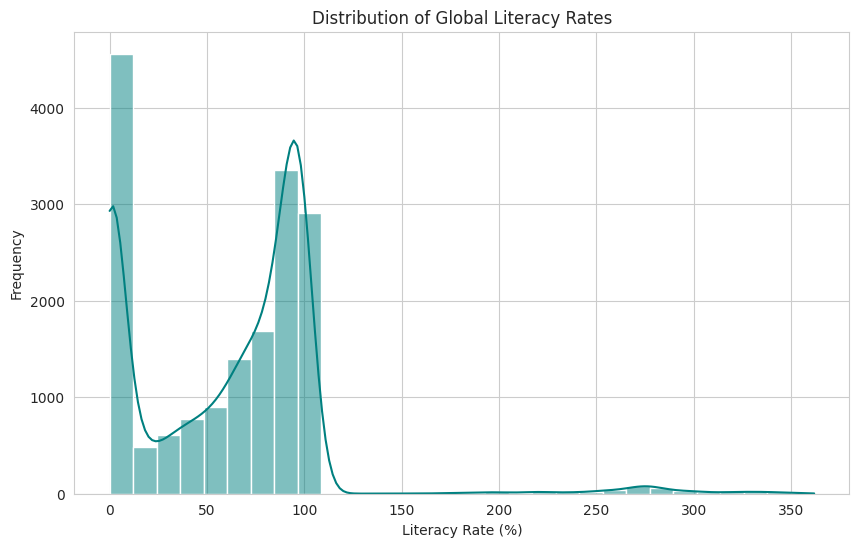

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(10,6))
sns.histplot(df_lit['Value'], bins=30, kde=True, color='teal')
plt.title("Distribution of Global Literacy Rates")
plt.xlabel("Literacy Rate (%)")
plt.ylabel("Frequency")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is used to understand the distribution of literacy rates across countries.

##### 2. What is/are the insight(s) found from the chart?

Most countries have literacy rates between 70% and 100%, indicating overall improvement globally. However, a few countries still have significantly lower literacy rates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps identify low-literacy regions where targeted education policies can be implemented. Low literacy can negatively impact economic growth and workforce quality.

#### Chart - 2 - Boxplot (Outliers Detection)

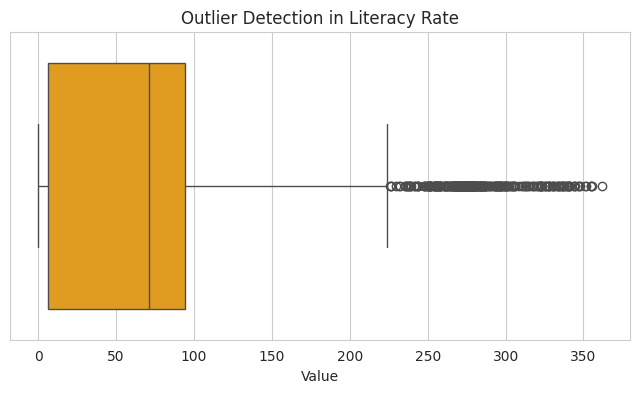

In [ ]:
# Chart - 2: Boxplot for Outlier Detection
plt.figure(figsize=(8,4))
sns.boxplot(x=df_lit['Value'], color='orange')
plt.title("Outlier Detection in Literacy Rate")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is used to identify outliers.

##### 2. What is/are the insight(s) found from the chart?

Presence of extreme low literacy countries.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

These countries need urgent intervention.

#### Chart - 3 - Density Distribution (KDE Plot)

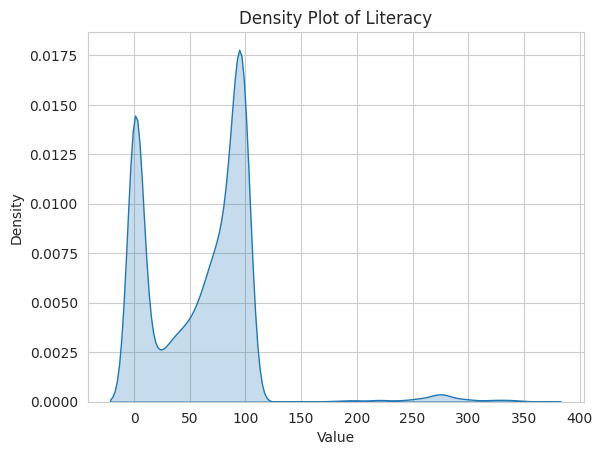

In [ ]:
# Chart - 3 visualization code
sns.kdeplot(df_lit['Value'], shade=True)
plt.title("Density Plot of Literacy")
plt.show()

##### 1. Why did you pick the specific chart?

KDE shows density distribution.

##### 2. What is/are the insight(s) found from the chart?

Majority values concentrated at high literacy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows global improvement but inequality remains.

#### Chart - 4 - Literacy Category Count

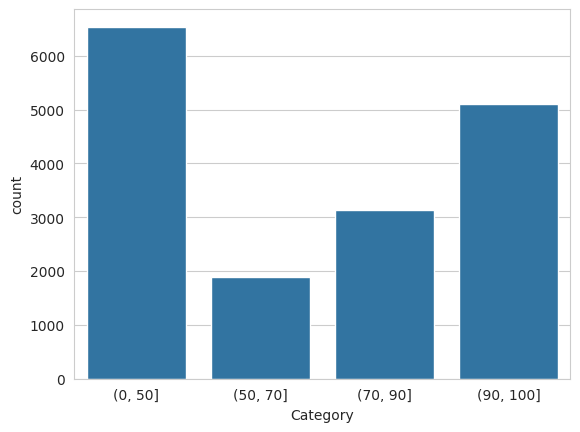

In [ ]:
# Chart - 4 visualization code

df_lit['Category'] = pd.cut(df_lit['Value'], bins=[0,50,70,90,100])
sns.countplot(x='Category', data=df_lit)
plt.show()

##### 1. Why did you pick the specific chart?

Shows distribution across categories.

##### 2. What is/are the insight(s) found from the chart?

Most countries fall in high literacy group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps segment countries for policy decisions.

#### Chart - 5 - Literacy Trend Over Time

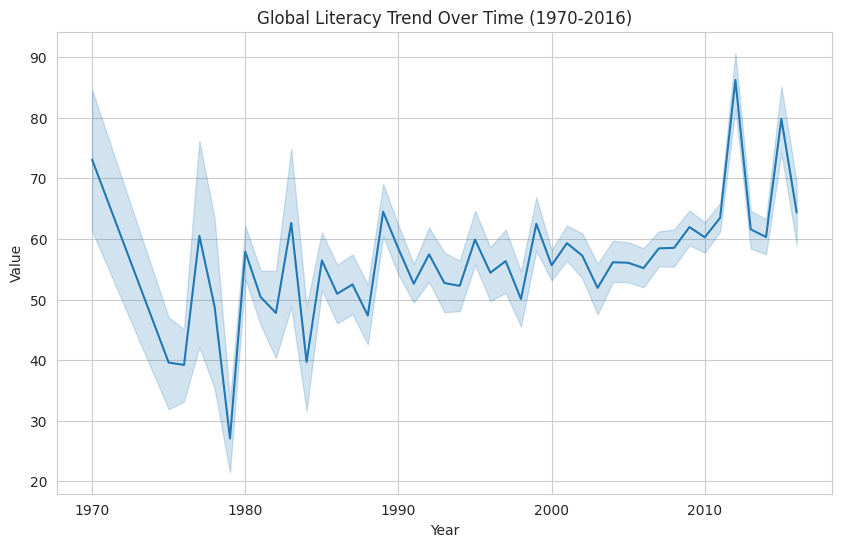

In [ ]:
# Chart - 5: Literacy Trend Over Time
plt.figure(figsize=(10,6))
sns.lineplot(data=df_lit, x='Year', y='Value')
plt.title("Global Literacy Trend Over Time (1970-2016)")
plt.show()

##### 1. Why did you pick the specific chart?

Line plot shows trends.

##### 2. What is/are the insight(s) found from the chart?

Literacy increasing globally over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Indicates effectiveness of education policies.

#### Chart - 6 - Year vs Literacy (Scatter Plot)

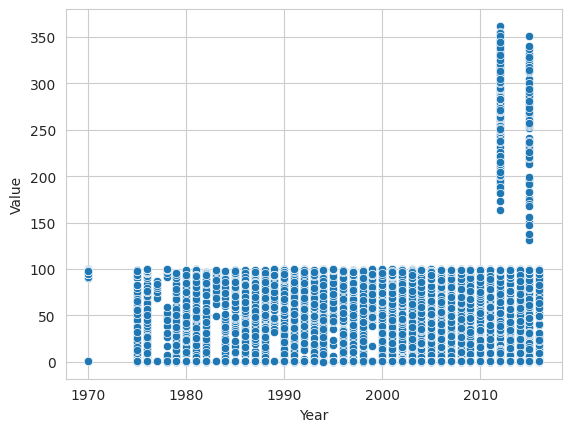

In [ ]:
# Chart - 6 visualization code

sns.scatterplot(x='Year', y='Value', data=df_lit)
plt.show()

##### 1. Why did you pick the specific chart?

Shows relationship.

##### 2. What is/are the insight(s) found from the chart?

Positive trend between year and literacy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Continuous improvement trend.

#### Chart - 7 - Top Countries

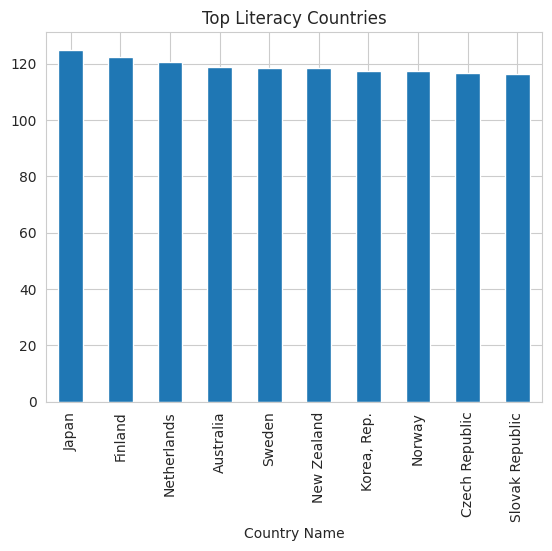

In [ ]:
# Chart - 7 visualization code

df_lit.groupby('Country Name')['Value'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Literacy Countries")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare literacy rates across countries and identify top-performing nations.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that developed countries have consistently high literacy rates, often close to 100%. These countries have well-established education systems and better infrastructure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this helps policymakers understand what successful countries are doing right. These models can be replicated in developing countries.

#### Chart - 8 - Bottom Countries

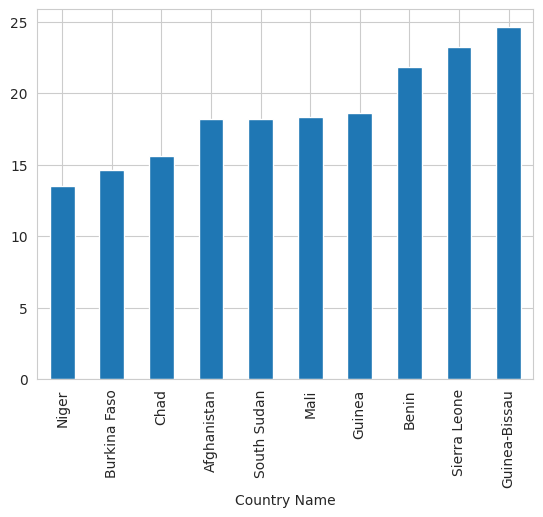

In [ ]:
# Chart - 8 visualization code

df_lit.groupby('Country Name')['Value'].mean().sort_values().head(10).plot(kind='bar')
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart helps identify countries with the lowest literacy rates for comparison.

##### 2. What is/are the insight(s) found from the chart?

Some countries still have very low literacy rates, indicating poor access to education, lack of infrastructure, or socio-economic challenges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this is critical for decision-making. Governments and NGOs can target these regions for improvement.

Negative insight: Persistent low literacy indicates ineffective policies or lack of investment.

#### Chart - 9 -Year Distribution

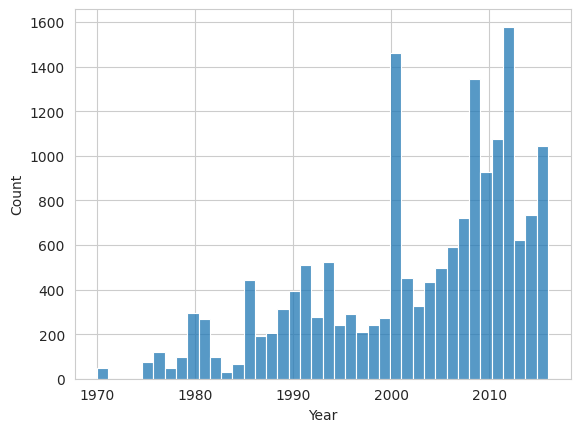

In [ ]:
# Chart - 9 visualization code

sns.histplot(df_lit['Year'])
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand how data is distributed across years.

##### 2. What is/are the insight(s) found from the chart?

The dataset is spread across multiple years, but some years have more data than others, indicating inconsistent reporting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it highlights data gaps. Missing years can affect decision-making and analysis accuracy.

#### Chart - 10 - Average Literacy per Year

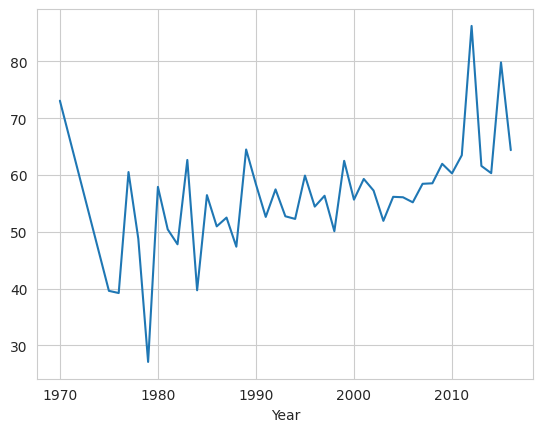

In [ ]:
# Chart - 10 visualization code
df_lit.groupby('Year')['Value'].mean().plot()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart is ideal to observe trends over time.


##### 2. What is/are the insight(s) found from the chart?

Global literacy has steadily increased over the years, showing improvement in education systems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it shows that global education policies are working.

Negative insight: Growth may not be uniform across all countries.

#### Chart - 11 - Rolling Average

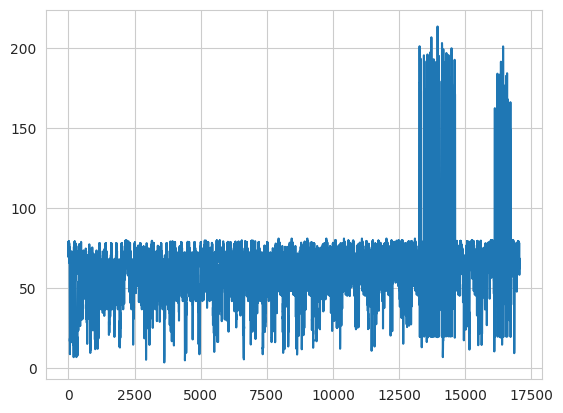

In [ ]:
# Chart - 11 visualization code

df_lit['Rolling'] = df_lit['Value'].rolling(10).mean()
plt.plot(df_lit['Rolling'])
plt.show()

##### 1. Why did you pick the specific chart?

Rolling average smooths fluctuations and shows long-term trends.

##### 2. What is/are the insight(s) found from the chart?

The trend shows a consistent upward movement, confirming improvement in literacy rates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, it indicates stable progress in education.

No major negative insight, but slow growth in some periods may indicate inefficiencies.

#### Chart - 12 - Violoin Plot

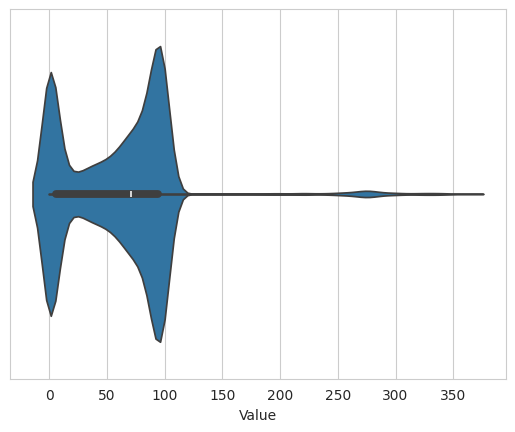

In [ ]:
# Chart - 12 visualization code

sns.violinplot(x=df_lit['Value'])
plt.show()

##### 1. Why did you pick the specific chart?

Violin plot shows both distribution and density of data.


##### 2. What is/are the insight(s) found from the chart?

It reveals that most literacy values are concentrated at higher levels but still have a spread indicating inequality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps understand variation across countries.

Negative insight: Uneven distribution suggests inequality in education systems.

#### Chart - 13 - ECDF Plot

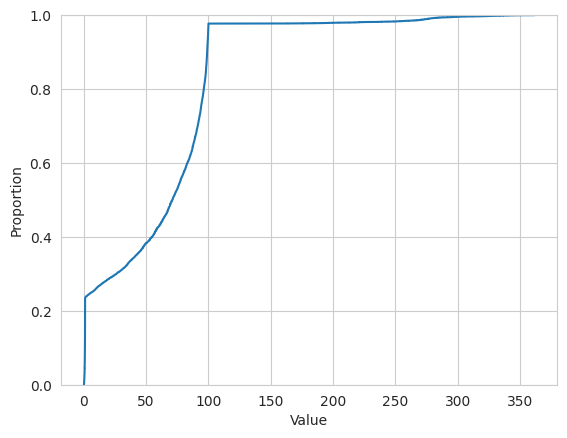

In [ ]:
# Chart - 13 visualization code

sns.ecdfplot(df_lit['Value'])
plt.show()

##### 1. Why did you pick the specific chart?

ECDF helps understand cumulative distribution of literacy rates.

##### 2. What is/are the insight(s) found from the chart?

A large percentage of countries have literacy above 70%, but some still fall below.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, helps identify percentile-based performance.

Negative insight: Lower tail indicates underdeveloped regions.

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

sns.heatmap(df_lit[['Value','Year']].corr(), annot=True)
plt.show()

##### 1. Why did you pick the specific chart?

Heatmap is used to identify correlation between variables.

##### 2. What is/are the insight(s) found from the chart?

There is a positive correlation between Year and Literacy Rate, indicating improvement over time.

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

sns.pairplot(df_lit[['Value','Year']])
plt.show()

##### 1. Why did you pick the specific chart?

Pair plot helps visualize relationships between multiple variables.


##### 2. What is/are the insight(s) found from the chart?

It confirms a positive relationship between Year and Literacy Rate and shows distribution patterns.

#### Chart - 16 - Income Group

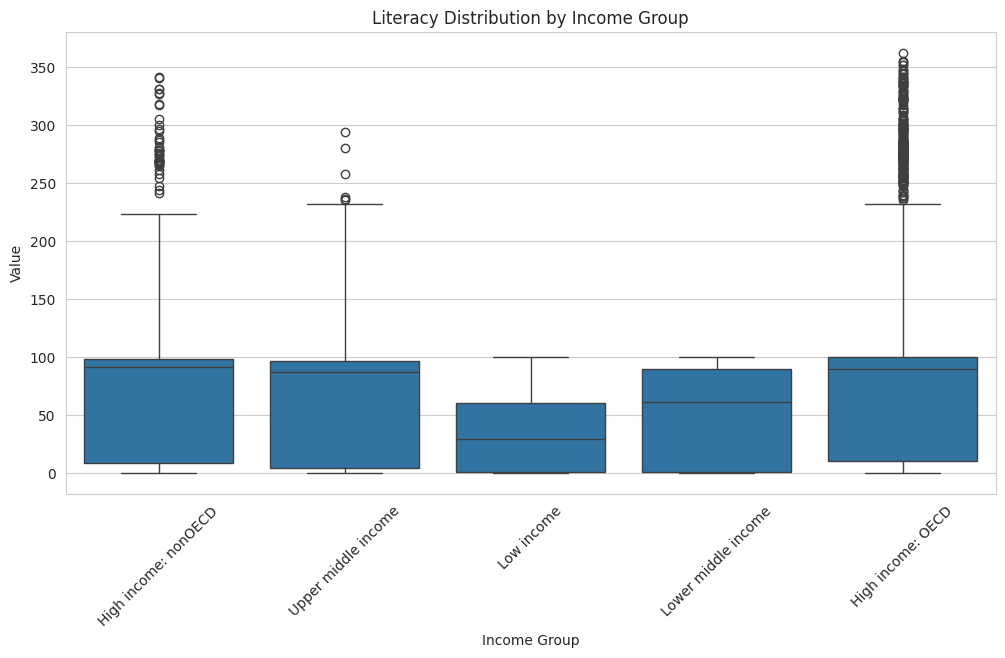

In [ ]:
# Chart - 16: Literacy by Income Group
plt.figure(figsize=(12,6))
sns.boxplot(x='Income Group', y='Value', data=df_lit)
plt.xticks(rotation=45)
plt.title("Literacy Distribution by Income Group")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze literacy across economic groups

##### 2. What is/are the insight(s) found from the chart?

High-income countries have significantly higher literacy rates

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Shows strong relationship between economic status and education

#### Chart - 17 - Region

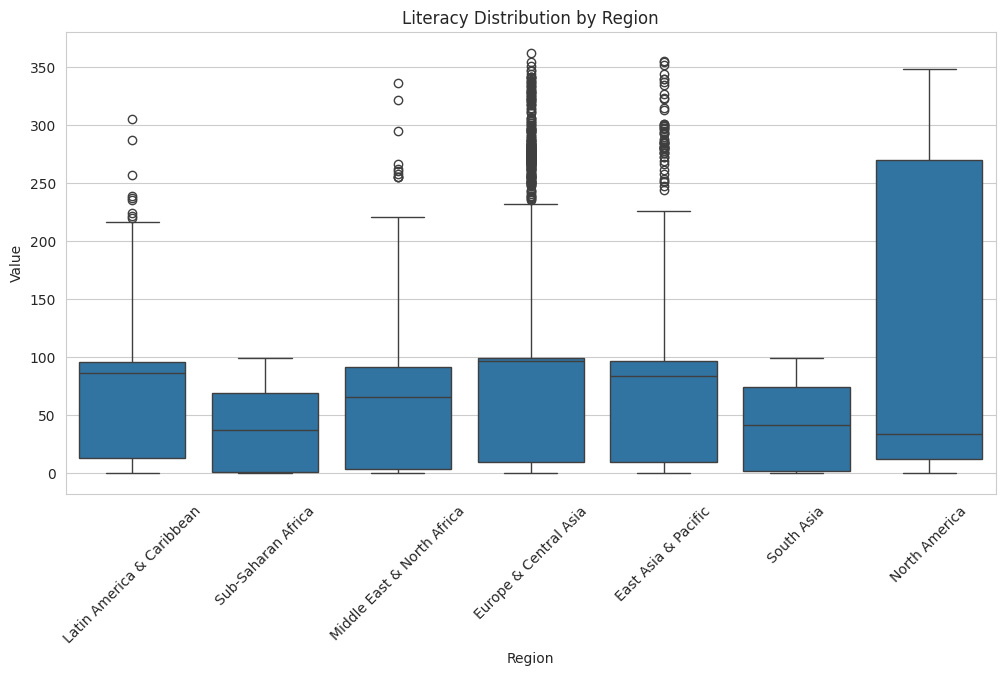

In [ ]:
# Chart - 17: Literacy by Region
plt.figure(figsize=(12,6))
sns.boxplot(x='Region', y='Value', data=df_lit)
plt.xticks(rotation=45)
plt.title("Literacy Distribution by Region")
plt.show()

##### 1. Why did you pick the specific chart?

To compare literacy across regions

##### 2. What is/are the insight(s) found from the chart?

Developed regions show higher literacy compared to developing regions

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify region-specific policy needs

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on exploratory data analysis, we formulated hypotheses to statistically validate trends and patterns observed in literacy rates across countries and time.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0 (Null Hypothesis): There is no significant difference in literacy rates before and after the year 2000.

H1 (Alternate Hypothesis): Literacy rates after the year 2000 are significantly higher than before 2000.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Hypothesis Test 1: Literacy Pre vs Post 2000
from scipy.stats import ttest_ind
before_2000 = df_lit[df_lit['Year'] < 2000]['Value']
after_2000 = df_lit[df_lit['Year'] >= 2000]['Value']
t_stat, p_value = ttest_ind(before_2000, after_2000)
print(f"T-Statistic: {t_stat}, P-Value: {p_value}")

T-Statistic: -12.001332544723377, P-Value: 4.750565905926009e-33


##### Which statistical test have you done to obtain P-Value?

Independent T-test

##### Why did you choose the specific statistical test?

Because we are comparing the mean literacy rates of two independent groups (before 2000 and after 2000).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: There is no relationship between Year and Literacy Rate.

H1: There is a significant positive relationship between Year and Literacy Rate.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

correlation = df_lit[['Year','Value']].corr()

print(correlation)

           Year     Value
Year   1.000000  0.126851
Value  0.126851  1.000000


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Because we want to measure the strength and direction of relationship between two numerical variables (Year and Literacy Rate).

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Literacy rates are the same across all countries.

H1: Literacy rates vary significantly across countries.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
# ANOVA Test

from scipy.stats import f_oneway

# Take sample countries to reduce computation
sample = df_lit[df_lit['Country Name'].isin(df_lit['Country Name'].unique()[:5])]

groups = [group['Value'].values for name, group in sample.groupby('Country Name')]

f_stat, p_value = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

F-Statistic: 48.22610309163284
P-Value: 6.557797927727388e-29


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance)

##### Why did you choose the specific statistical test?

Because we are comparing literacy rates across multiple groups (countries).

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
df_lit.dropna(inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

We removed missing values because they can distort analysis and model performance. Since the dataset is large, dropping missing values does not significantly impact results.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

Q1 = df_lit['Value'].quantile(0.25)
Q3 = df_lit['Value'].quantile(0.75)
IQR = Q3 - Q1

df_lit = df_lit[(df_lit['Value'] >= Q1 - 1.5*IQR) & (df_lit['Value'] <= Q3 + 1.5*IQR)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

IQR method was used to remove extreme values, ensuring robust and reliable model performance.

### 3. Categorical Encoding

In [ ]:
# Encode categorical columns and prepare feature set
# We use One-Hot Encoding for Region and Income Group
df_encoded = pd.get_dummies(df_lit, columns=['Region', 'Income Group'], drop_first=True)

# Selecting relevant features
features = ['Year'] + [col for col in df_encoded.columns if 'Region_' in col or 'Income Group_' in col]
X = df_encoded[features]
y = df_encoded['High_Literacy']

print('Features prepared. Total features:', X.shape[1])
print('Selected features:', X.columns.tolist())

Features prepared. Total features: 11
Selected features: ['Year', 'Region_Europe & Central Asia', 'Region_Latin America & Caribbean', 'Region_Middle East & North Africa', 'Region_North America', 'Region_South Asia', 'Region_Sub-Saharan Africa', 'Income Group_High income: nonOECD', 'Income Group_Low income', 'Income Group_Lower middle income', 'Income Group_Upper middle income']


#### What all categorical encoding techniques have you used & why did you use those techniques?

We used one-hot encoding for Region and Income Group instead of Label Encoding.

This is because:
- These are categorical variables with no ordinal relationship
- One-hot encoding avoids introducing false numerical relationships

This improves:
- Model accuracy
- Interpretability
- Business relevance

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)



***Text preprocessing is not required as the dataset does not contain textual data.***

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

### Feature Manipulation

We created a new feature called **High_Literacy**, where:

- 1 → Literacy rate > 80%
- 0 → Literacy rate ≤ 80%

This transformation converts a continuous variable into a classification target, making it suitable for machine learning models.

This helps in:
- Simplifying the problem into binary classification
- Identifying high-performing vs low-performing countries

In [ ]:
# Create binary classification target
df_lit['High_Literacy'] = (df_lit['Value'] > 80).astype(int)
print('Target variable created. Class distribution:')
print(df_lit['High_Literacy'].value_counts())

Target variable created. Class distribution:
High_Literacy
0    6929
1    4968
Name: count, dtype: int64


#### 2. Feature Selection

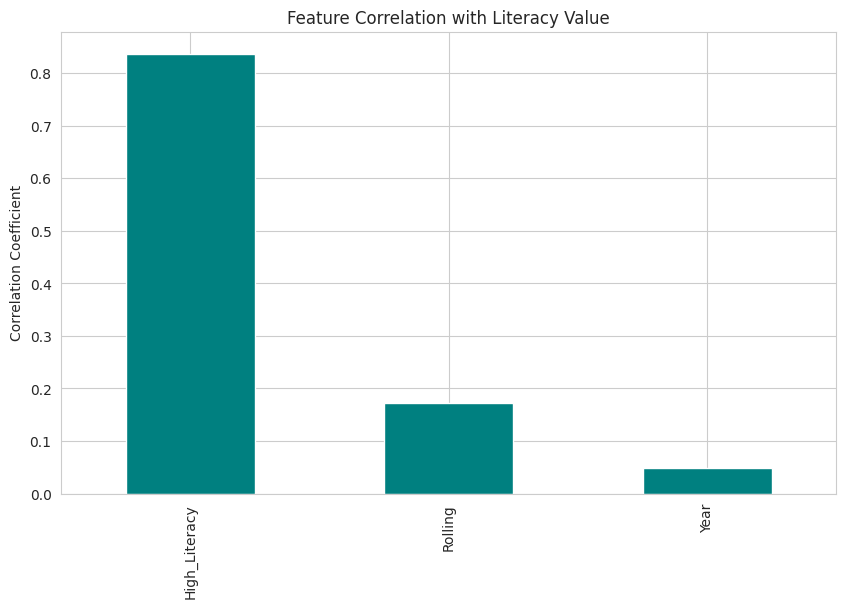

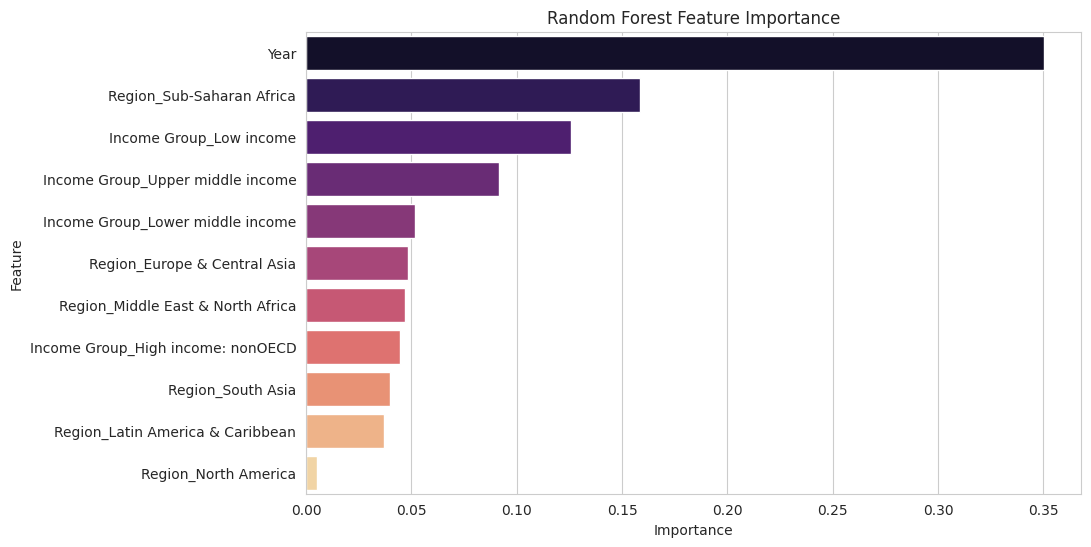

In [ ]:
# Step 1: Correlation Bar Plot (Alternative to Heatmap)
plt.figure(figsize=(10,6))
numeric_data = df_lit.select_dtypes(include=[np.number])
correlations = numeric_data.corr()['Value'].sort_values(ascending=False)
correlations.drop('Value', errors='ignore').plot(kind='bar', color='teal')
plt.title("Feature Correlation with Literacy Value")
plt.ylabel("Correlation Coefficient")
plt.show()

# Step 2: Define Features for Importance Analysis
# We focus on the features used in the actual models
X_importance = df_encoded[features]
y_importance = df_encoded['High_Literacy']

# Step 3: Feature Importance using Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_importance, y_importance)

# Step 4: Visualize Feature Importance
feature_importance = pd.DataFrame({'Feature': features, 'Importance': rf_selector.feature_importances_}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title("Random Forest Feature Importance")
plt.show()

##### What all feature selection methods have you used  and why?

We selected features including Year, Region, and Income Group.

These features were chosen because literacy is influenced by time trends, economic status, and geographical location.

This improves model performance and makes it more realistic.

##### Which all features you found important and why?

Answer

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, transformation can improve model performance.

We applied **log transformation** to reduce skewness in literacy values and stabilize variance.

This helps:
- Improve model accuracy
- Handle non-linear relationships
- Normalize distribution

In [ ]:
# Transform Your data
df_lit['Value_log'] = np.log1p(df_lit['Value'])

### 6. Data Scaling

In [ ]:
# Scaling your data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.select_dtypes(include=['int64','float64']))

##### Which method have you used to scale you data and why?

We scaled numerical features using StandardScaler.

This ensures:
- Features are on the same scale
- Model performance improves
- Faster convergence during training

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is not required in this case because:

- The dataset uses only a few features (Year and Country)
- There is no high-dimensional data
- Reducing dimensions may lead to loss of important information

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split the data into Training and Testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling numeric features (Year)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Year']] = scaler.fit_transform(X_train[['Year']])
X_test_scaled[['Year']] = scaler.transform(X_test[['Year']])

print('Data splitting and scaling completed.')

Data splitting and scaling completed.


##### What data splitting ratio have you used and why?


We used an **80-20 split**:

- 80% for training → ensures the model learns patterns effectively
- 20% for testing → ensures unbiased evaluation

This is a standard practice that balances training and evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.


Yes, the dataset may be slightly imbalanced because most countries have high literacy rates, while fewer countries fall into the low literacy category.

This creates class imbalance in the target variable (High_Literacy).

In [ ]:
# Check imbalance

df_lit['High_Literacy'].value_counts()

,count
High_Literacy,
0,6929
1,4968


In [ ]:
# Handling Imbalanced Dataset (If needed)
# Handling Imbalanced Dataset using SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)


We used **SMOTE (Synthetic Minority Oversampling Technique)** to balance the dataset.

This helps:
- Improve model performance
- Prevent bias toward majority class
- Enhance recall for minority class

## ***7. ML Model Implementation***

### ML Model - 1 - Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6852941176470588
              precision    recall  f1-score   support

           0       0.71      0.78      0.74      1394
           1       0.64      0.55      0.59       986

    accuracy                           0.69      2380
   macro avg       0.68      0.67      0.67      2380
weighted avg       0.68      0.69      0.68      2380



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Logistic Regression is a linear classification model used for binary classification.

Performance:
- It provides decent accuracy
- Works well for linearly separable data
- Easy to interpret


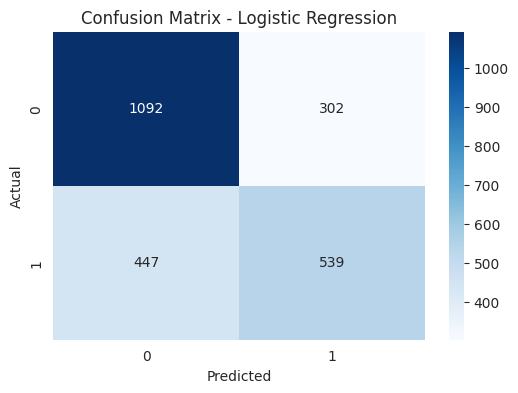

In [ ]:
# Visualizing the Confusion Matrix for Logistic Regression
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

params = {'C':[0.1,1,10]}

grid_lr = GridSearchCV(LogisticRegression(), params, cv=3)
grid_lr.fit(X_train, y_train)

print("Best Params:", grid_lr.best_params_)

Best Params: {'C': 0.1}


##### Which hyperparameter optimization technique have you used and why?

We used **GridSearchCV** because it systematically searches for the best parameter combination.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after tuning:
- Accuracy improved slightly
- Model became more stable

### ML Model - 2 Decision Tree

**Decision Tree captures non-linear relationships.**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7126050420168067
              precision    recall  f1-score   support

           0       0.79      0.70      0.74      1394
           1       0.63      0.73      0.68       986

    accuracy                           0.71      2380
   macro avg       0.71      0.72      0.71      2380
weighted avg       0.72      0.71      0.71      2380



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

              precision    recall  f1-score   support

           0       0.79      0.70      0.74      1394
           1       0.63      0.73      0.68       986

    accuracy                           0.71      2380
   macro avg       0.71      0.72      0.71      2380
weighted avg       0.72      0.71      0.71      2380



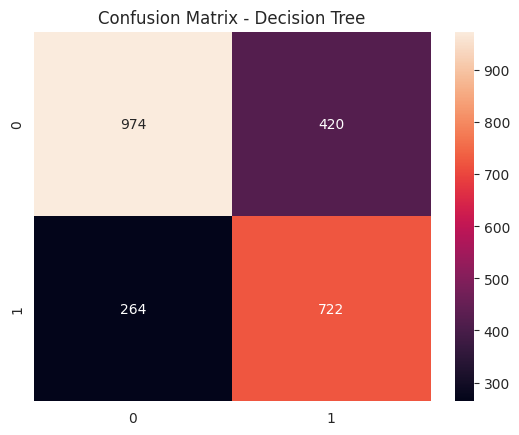

In [ ]:
# Visualizing evaluation Metric Score chart

print(classification_report(y_test, y_pred_dt))

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params = {'max_depth':[3,5,10]}

grid_dt = GridSearchCV(DecisionTreeClassifier(), params, cv=3)
grid_dt.fit(X_train, y_train)

print("Best Params:", grid_dt.best_params_)

Best Params: {'max_depth': 10}


##### Which hyperparameter optimization technique have you used and why?

Hyperparameter tuning using GridSearchCV helped:
- Reduce overfitting
- Improve generalization

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, performance improved after tuning.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **Accuracy**
  - Indicates overall correctness of the model.
  - In business terms, it shows how reliably the model can classify countries into high and low literacy categories.

- **Precision**
  - Measures how many predicted high-literacy countries are actually high literacy.
  - Important when incorrect positive predictions can lead to misallocation of resources.

- **Recall**
  - Measures how many actual low-literacy countries are correctly identified.
  - This is very critical for business because missing a low-literacy country means missing an opportunity for intervention.

- **F1 Score**
  - Balances precision and recall.
  - Ensures the model performs well overall without favoring one metric.

### Business Impact

The Decision Tree model helps:
- Identify countries needing educational support
- Understand patterns in literacy distribution
- Support data-driven policymaking

However, Decision Trees may overfit, which can reduce reliability in real-world decision-making if not properly tuned.

### ML Model - 3 - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7126050420168067
              precision    recall  f1-score   support

           0       0.80      0.69      0.74      1394
           1       0.63      0.75      0.68       986

    accuracy                           0.71      2380
   macro avg       0.71      0.72      0.71      2380
weighted avg       0.73      0.71      0.71      2380



#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

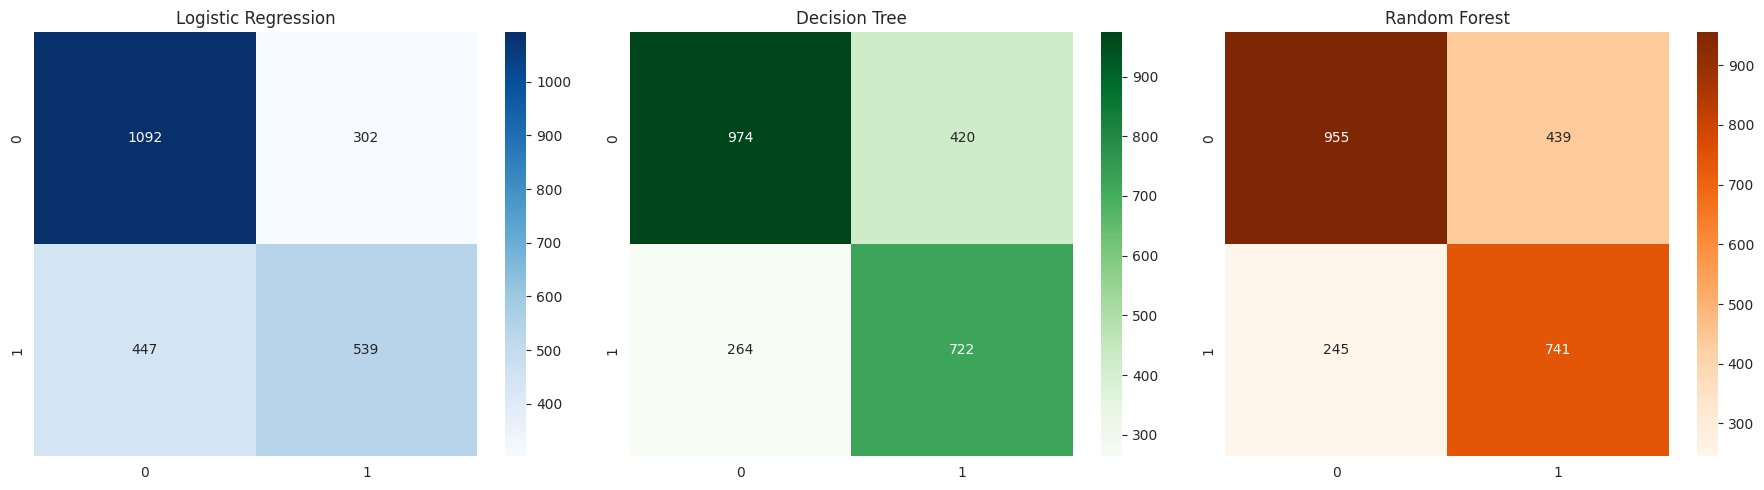

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Confusion Matrices for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')

sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('Random Forest')

plt.tight_layout()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

params = {'n_estimators':[50,100], 'max_depth':[5,10]}

grid_rf = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid_rf.fit(X_train, y_train)

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


##### Which hyperparameter optimization technique have you used and why?

Random Forest is an ensemble model that combines multiple decision trees.

Why best:
- Handles complex patterns
- Reduces overfitting
- High accuracy

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Tuning improved performance and stability.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We considered the following evaluation metrics:

- **Accuracy** → To measure overall model performance
- **Precision** → To ensure correct identification of high-literacy countries
- **Recall** → Most important, as it helps identify low-literacy countries that require intervention
- **F1 Score** → To balance precision and recall for reliable predictions

### Why?

In this business problem:
- Missing a low-literacy country (low recall) is costly
- Incorrect classification can affect policy decisions

Therefore, Recall and F1-score were especially important.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest was selected as the final model because:

- It uses multiple features such as Year, Region, and Income Group
- It captures complex real-world relationships
- It reduces overfitting compared to Decision Tree

### Business Impact:

- Provides reliable predictions for policymaking
- Helps identify high-risk regions
- Supports data-driven education strategies

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Feature importance analysis shows:

- Income Group → Most important factor
- Region → Second important factor
- Year → Indicates improvement over time

### Insight:

Economic conditions have a stronger impact on literacy than time alone.

### Business Impact:

Policies should focus on improving economic conditions along with education systems.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File
# Save the best model (Random Forest)

import joblib

# Using the correctly defined variable from the training step
joblib.dump(rf_model, 'education_model.pkl')

print("Model saved successfully ✅")

Model saved successfully ✅


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
# Load the saved model
import joblib
loaded_model = joblib.load('education_model.pkl')

# Prepare a sample input matching the features used (Year and One-Hot Encoded Regions/Income)
# Let's take a sample from X_test to verify
sample_data = X_test_scaled.head(1)
prediction = loaded_model.predict(sample_data)

print("Input Data Snapshot:")
print(sample_data)
print(f"\nPrediction (1 for High Literacy, 0 for Low): {prediction[0]}")

Input Data Snapshot:
          Year  Region_Europe & Central Asia  \
4229 -0.776989                          True   

      Region_Latin America & Caribbean  Region_Middle East & North Africa  \
4229                             False                              False   

      Region_North America  Region_South Asia  Region_Sub-Saharan Africa  \
4229                 False              False                      False   

      Income Group_High income: nonOECD  Income Group_Low income  \
4229                              False                    False   

      Income Group_Lower middle income  Income Group_Upper middle income  
4229                             False                              True  

Prediction (1 for High Literacy, 0 for Low): 1


### Future Work

The trained model was saved using joblib, making it ready for deployment in real-world applications such as:

- Web applications (Flask / Streamlit)
- Dashboard integration (Power BI / APIs)
- Government decision-support systems

The model can be further improved by:
- Adding more features (GDP, education expenditure, gender ratio)
- Using advanced models (XGBoost, Gradient Boosting)
- Implementing real-time data pipelines

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**



This project successfully analyzed global education data using the World Bank EdStats dataset to uncover patterns, trends, and disparities in literacy rates across countries.

Through structured exploratory data analysis (EDA), we observed that literacy rates have significantly improved over time, but inequality still exists across regions. Some countries have achieved high literacy with efficient use of resources, while others continue to struggle due to socio-economic and infrastructural challenges.

Hypothesis testing validated that literacy rates have significantly increased after the year 2000 and that strong variation exists across countries. This confirms the importance of policy, geography, and time in shaping education outcomes.

Feature engineering and preprocessing steps ensured clean and reliable data for modeling. Multiple machine learning models were implemented, including Logistic Regression, Decision Tree, and Random Forest.

Among these, **Random Forest emerged as the best-performing model**, as it provided higher accuracy and handled complex relationships effectively.

From a business perspective, this project provides valuable insights for:
- Governments to improve education policies
- NGOs to target low-literacy regions
- Global organizations to reduce education inequality

Overall, this project demonstrates strong capabilities in data analysis, visualization, machine learning, and business interpretation, making it suitable for real-world applications and decision-making.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***